# Filtrado  de datos

In [ ]:
import pandas as pd
import numpy as np
import math
from google.colab import drive
import matplotlib.pyplot as plt
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ruta = '/content/drive/MyDrive/A_A/Préstamo.csv'

In [ ]:
df = pd.read_csv(ruta, sep=',', encoding='latin-1')

In [ ]:
misColumnas = 'Edad','Sexo','Mayor nivel educativo','Estado de vivienda','Préstamos previos impagos','Estado'
df1 = df.loc[:,misColumnas]
df_40_45 = df1[(df1["Edad"] >=40) & (df1["Edad"] <= 45) ]
df_40_45 = df_40_45.drop('Edad', axis=1)
print("cantidad de registros",df_40_45['Sexo'].count())

cantidad de registros 1426


In [ ]:
df_40_45 = df_40_45.sample(frac=1, random_state=42).reset_index(drop=True)
corte = int(len(df_40_45) * 0.8)
df_40_45_entrenamiento = df_40_45.iloc[:corte]
df_40_45_test = df_40_45.iloc[corte:]
print('Cantidad entrenamiento:',len(df_40_45_entrenamiento))
print('Cantidad prueba:',len(df_40_45_test))

Cantidad entrenamiento: 1140
Cantidad prueba: 286


In [ ]:
conteo = df_40_45_entrenamiento['Estado'].value_counts()
for clase in conteo.index:
    cantidad = conteo[clase]
    print(clase, cantidad)

RECHAZADO 904
OTORGADO 236


# Arbol

In [ ]:
def entropiaShanon(df, columna_clase):
  conteo = df[columna_clase].value_counts()
  total = len(df)
  entropia_total = 0

  for cantidad in conteo:

      p = cantidad / total
      entropia_total += -p * math.log2(p)
  max_ganancia = -1
  max_atributo = None
  for atributo in df.columns:
    if atributo != columna_clase:
        entropia_atributo = 0
        conteo_atributo = df[atributo].value_counts()
        for categoria in conteo_atributo.index:
            sub = df[df[atributo] == categoria]
            total_categoria = len(sub)
            entropia_categoria = 0
            conteo_clases = sub[columna_clase].value_counts()
            for etiqueta in conteo_clases.index:
                cantidad = conteo_clases[etiqueta]
                p = cantidad / total_categoria
                entropia_categoria += -p * math.log2(p)
            peso = total_categoria / total
            entropia_atributo += peso * entropia_categoria
        ganancia = entropia_total - entropia_atributo
        if ganancia > max_ganancia:
          max_ganancia=ganancia
          max_atributo=atributo
  return max_atributo

entropiaShanon(df_40_45_entrenamiento,'Estado')



'Préstamos previos impagos'

In [ ]:
def construir_arbol(df, columna_clase):
    if df.empty:
        return None
    if df[columna_clase].nunique() == 1:
        return {
            'resultado': df[columna_clase].iloc[0]
        }
    if len(df.columns) == 1:
        return {
            'resultado': df[columna_clase].mode()[0]
        }
    mejor_atributo = entropiaShanon(df, columna_clase)
    arbol = {
        'atributo': mejor_atributo,
        'ramas': {}
    }
    for categoria in df[mejor_atributo].unique():
        subc = df[df[mejor_atributo] == categoria]
        subc = subc.drop(mejor_atributo, axis=1)
        subarbol = construir_arbol(subc, columna_clase)
        arbol['ramas'][categoria] = subarbol
    return arbol

In [ ]:
def mostrar_arbol(arbol, nivel=0):
    if 'resultado' in arbol:
        print('  ' * nivel + '→', arbol['resultado'])
        return
    print('  ' * nivel + '[' + arbol['atributo'] + ']')
    for categoria, subarbol in arbol['ramas'].items():
        print('  ' * (nivel + 1) + categoria)
        mostrar_arbol(subarbol, nivel + 2)

In [ ]:
arbol = construir_arbol(df_40_45_entrenamiento,'Estado')
mostrar_arbol(arbol)

[Préstamos previos impagos]
  SI
    → RECHAZADO
  NO
    [Estado de vivienda]
      HIPOTECA
        [Mayor nivel educativo]
          TERCIARIO
            [Sexo]
              MASCULINO
                → RECHAZADO
              FEMENINO
                → RECHAZADO
          SECUNDARIO
            [Sexo]
              MASCULINO
                → RECHAZADO
              FEMENINO
                → RECHAZADO
          DOCTORADO
            [Sexo]
              MASCULINO
                → RECHAZADO
              FEMENINO
                → OTORGADO
          MAESTRíA
            [Sexo]
              MASCULINO
                → RECHAZADO
              FEMENINO
                → RECHAZADO
          UNIVERSITARIO
            [Sexo]
              FEMENINO
                → RECHAZADO
              MASCULINO
                → RECHAZADO
      INQUILINO
        [Mayor nivel educativo]
          SECUNDARIO
            [Sexo]
              FEMENINO
                → OTORGADO
              MASCULINO

# Ejecución

In [ ]:
def predecir_fila(arbol, fila):
    if 'resultado' in arbol:
        return arbol['resultado']
    atributo = arbol['atributo']
    valor_fila = fila[atributo]
    if valor_fila in arbol['ramas']:
        return predecir_fila(arbol['ramas'][valor_fila], fila)
    else:
        return 'RECHAZADO'
y_pred = df_40_45_test.apply(lambda fila: predecir_fila(arbol, fila), axis=1)
df_40_45_test = df_40_45_test.copy()
df_40_45_test['Prediccion'] = y_pred
print(df_40_45_test[['Estado', 'Prediccion']].head(10))

         Estado Prediccion
1140  RECHAZADO   OTORGADO
1141   OTORGADO  RECHAZADO
1142  RECHAZADO  RECHAZADO
1143  RECHAZADO   OTORGADO
1144  RECHAZADO  RECHAZADO
1145  RECHAZADO  RECHAZADO
1146  RECHAZADO  RECHAZADO
1147  RECHAZADO  RECHAZADO
1148  RECHAZADO  RECHAZADO
1149  RECHAZADO  RECHAZADO


In [ ]:
def evaluar_modelo(y_real, y_pred):
    TP = 0
    TN = 0
    FP = 0
    FN = 0
    for real, pred in zip(y_real, y_pred):
        if real == 'OTORGADO' and pred == 'OTORGADO':
            TP += 1
        elif real == 'RECHAZADO' and pred == 'RECHAZADO':
            TN += 1
        elif real == 'RECHAZADO' and pred == 'OTORGADO':
            FP += 1
        elif real == 'OTORGADO' and pred == 'RECHAZADO':
            FN += 1

    total = TP + TN + FP + FN
    accuracy = (TP + TN) / total if total > 0 else 0

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0

    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print("Matriz de Confusión")
    print(f"Verdaderos Positivos (TP): {TP}")
    print(f"Verdaderos Negativos (TN): {TN}")
    print(f"Falsos Positivos (FP): {FP}")
    print(f"Falsos Negativos (FN): {FN}")
    print("-" * 40)

    print("Métricas de Evaluación")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score: {f1_score:.4f}")

evaluar_modelo(df_40_45_test['Estado'], df_40_45_test['Prediccion'])

Matriz de Confusión
Verdaderos Positivos (TP): 22
Verdaderos Negativos (TN): 207
Falsos Positivos (FP): 20
Falsos Negativos (FN): 37
----------------------------------------
Métricas de Evaluación
Accuracy: 0.8007
F1-Score: 0.4356


2


In [ ]:
def entrenar_random_forest(df_train, columna_clase, n_arboles=10, semilla=42):
    if semilla is not None:
        np.random.seed(semilla)
    bosque = []
    n_filas = len(df_train)
    for i in range(n_arboles):
        indices_bootstrap = np.random.choice(n_filas, size=n_filas, replace=True)
        df_bootstrap = df_train.iloc[indices_bootstrap].reset_index(drop=True)
        arbol = construir_arbol(df_bootstrap, columna_clase)
        bosque.append(arbol)
    return bosque

In [ ]:
def predecir_random_forest(bosque, fila):
    votos_otorgado = 0
    votos_rechazado = 0
    for arbol in bosque:
        voto = predecir_fila(arbol, fila)
        if voto == 'OTORGADO':
            votos_otorgado += 1
        else:
            votos_rechazado += 1
    if votos_otorgado > votos_rechazado:
        return 'OTORGADO'
    else:
        return 'RECHAZADO'

In [ ]:
mi_bosque = entrenar_random_forest(df_40_45_entrenamiento, 'Estado', n_arboles=10)
y_pred_bosque = df_40_45_test.apply(lambda fila: predecir_random_forest(mi_bosque, fila), axis=1)

df_40_45_test['Prediccion_RF'] = y_pred_bosque
print(df_40_45_test[['Estado', 'Prediccion', 'Prediccion_RF']].head(10))

         Estado Prediccion Prediccion_RF
1140  RECHAZADO   OTORGADO     RECHAZADO
1141   OTORGADO  RECHAZADO     RECHAZADO
1142  RECHAZADO  RECHAZADO     RECHAZADO
1143  RECHAZADO   OTORGADO     RECHAZADO
1144  RECHAZADO  RECHAZADO     RECHAZADO
1145  RECHAZADO  RECHAZADO     RECHAZADO
1146  RECHAZADO  RECHAZADO     RECHAZADO
1147  RECHAZADO  RECHAZADO     RECHAZADO
1148  RECHAZADO  RECHAZADO     RECHAZADO
1149  RECHAZADO  RECHAZADO      OTORGADO


In [ ]:
evaluar_modelo(df_40_45_test['Estado'], df_40_45_test['Prediccion_RF'])

Matriz de Confusión
Verdaderos Positivos (TP): 14
Verdaderos Negativos (TN): 209
Falsos Positivos (FP): 18
Falsos Negativos (FN): 45
----------------------------------------
Métricas de Evaluación
Accuracy: 0.7797
F1-Score: 0.3077


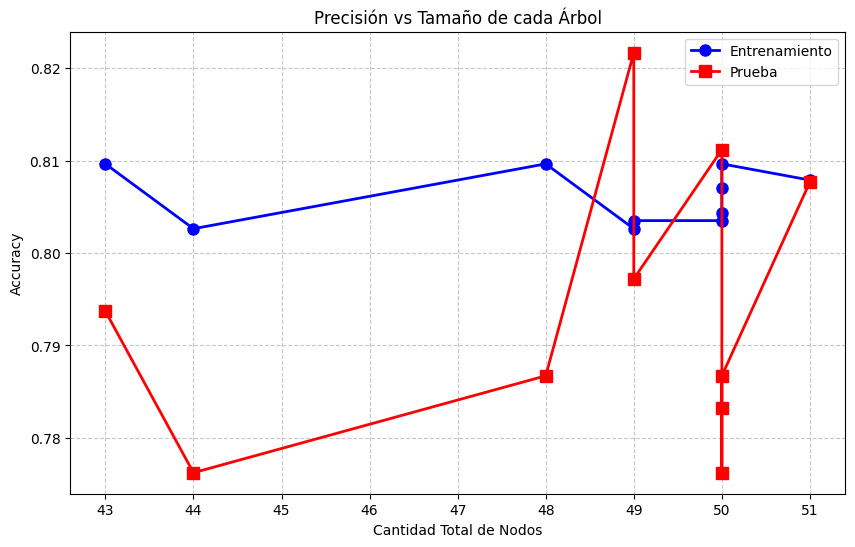

In [ ]:
def calcular_tamano_arbol(arbol):
    if 'resultado' in arbol:
        return 1
    tamano = 1
    for rama in arbol['ramas'].values():
        tamano += calcular_tamano_arbol(rama)
    return tamano

tamanos_desordenados = []
acc_train_desordenado = []
acc_test_desordenado = []

for arbol in mi_bosque:
    tamanos_desordenados.append(calcular_tamano_arbol(arbol))
    pred_train = df_40_45_entrenamiento.apply(lambda fila: predecir_fila(arbol, fila), axis=1)
    aciertos_tr = sum((real == pred) for real, pred in zip(df_40_45_entrenamiento['Estado'], pred_train))
    acc_train_desordenado.append(aciertos_tr / len(df_40_45_entrenamiento))
    pred_test = df_40_45_test.apply(lambda fila: predecir_fila(arbol, fila), axis=1)
    aciertos_te = sum((real == pred) for real, pred in zip(df_40_45_test['Estado'], pred_test))
    acc_test_desordenado.append(aciertos_te / len(df_40_45_test))

datos_ordenados = sorted(zip(tamanos_desordenados, acc_train_desordenado, acc_test_desordenado))

tamanos = [d[0] for d in datos_ordenados]
acc_train = [d[1] for d in datos_ordenados]
acc_test = [d[2] for d in datos_ordenados]

plt.figure(figsize=(10, 6))

plt.plot(tamanos, acc_train, color='blue', label='Entrenamiento', marker='o', linestyle='-', linewidth=2, markersize=8)
plt.plot(tamanos, acc_test, color='red', label='Prueba', marker='s', linestyle='-', linewidth=2, markersize=8)

plt.title('Precisión vs Tamaño de cada Árbol')
plt.xlabel('Cantidad Total de Nodos')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()